# Ноутбук для всяких картинок для отчетов

In [2]:
cd ../src/train_VAE

/home/rfit/Telescope_Array/phd_work/src/train_VAE


In [3]:
!pwd

/home/rfit/Telescope_Array/phd_work/src/train_VAE


In [4]:
import pipline







Using device: cuda


2026-04-02 12:40:11.143636: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775122811.159265   48540 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775122811.164405   48540 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775122811.177318   48540 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775122811.177342   48540 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775122811.177345   48540 computation_placer.cc:177] computation placer alr

In [5]:
pip = pipline.Pipline("config.yaml")

['catboost_info', 'pipline.py', '__pycache__', 'show_loss.py', 'model_old.py', 'metric.py', 'loss_hist.png', 'runs', 'test_runs', 'datasets.py', 'phd_work', 'runs_tests', 'model.py', 'loss.py', 'tests', 'utils.py', 'init.sh', 'config.yaml', '__init__.py', 'for_temporary_work', '.ipynb_checkpoints']
Encoder has params: 783944 Decoder has params: 2055719
split_num 10000 <class 'int'>
Saving Path: /home/rfit/Telescope_Array/phd_work/Models/AutoEncoder/info_Transfoemr_MMD_0.05_KL_0.01_new_MMD2_MMD_KL_0
self.koef_KL tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.], device='cuda:0', dtype=torch.float64)


In [9]:
for data,part,params_CR in pip.val_loaders[0]:
    print(data.shape)
    print(part.shape)
    print(params_CR.shape)
    break

torch.Size([150, 41, 6])
torch.Size([150])
torch.Size([150, 1])


In [10]:
from typing import Optional, Tuple, Union
import numpy as np
import torch
import matplotlib.pyplot as plt

def clean_mask(data: torch.Tensor, tokens: Optional[Tuple[int, int, int]] =None, lenght: Optional[int]=None) -> torch.Tensor:
    """
    This function cleans a masked tensor by removing start, end, and mask tokens, and adjusting the length accordingly.

    Parameters:
    - data (torch.Tensor): The input tensor to be cleaned. It should be of shape (sequence_length, features).
    - tokens (Optional[Tuple[int, int, int]]): A tuple containing the start token, end token, and mask token. If None, default values will be used.

    Returns:
    torch.Tensor: The cleaned tensor with the start, end, and mask tokens removed, and the length adjusted accordingly.
    """
    if lenght is not None:
        return data[:lenght], lenght
    st, fn, ms = tokens
    mask = torch.where(data != ms, 1, 0)
    lenght = torch.sum(mask[:,0]) # length but used st and fn tokens
    if fn is not None:
        lenght-=1 # fn token is not real data
    if st is not None:
        data = data[1:] # del first data
        lenght-=1
    return data[:lenght], lenght  

def show_data(data, tokens: Optional[Tuple[int, int, int]]=None,
               lenght_predict: Union[np.ndarray, torch.Tensor] = None) -> plt.figure:
    '''
    data - shape (det, featches)

    fake - shape (det, featches)

    return: fig
    '''

    #TODO переписать нормально
    data, real_lenght = clean_mask(data, tokens = tokens)
    names = ['det x', 'det y', 'det z', 'signal', 'flat front', '(real - front)']
    fig, axs = plt.subplots(2,3, figsize = (10,10))
    for i in range(6):
        row = i//3
        col = i%3
        axs[row][col].plot(data.to('cpu').detach().numpy()[:,i], 'or')
        #axs[row][col].plot(data.to('cpu').detach().numpy()[:,i], '--b')
        #axs[row][col].legend(['true', 'true'])
        axs[row][col].set_title(f'chanal {names[i]}')
        axs[row][col].grid()
    lenght_info = f'real_lenght {real_lenght}'
    plt.suptitle(lenght_info)
    return fig

In [3]:
import torch
t = torch.randn(5,5)
torch.abs(torch.min(t, dim=1, keepdim=True)[0])

tensor([[0.7926],
        [1.1463],
        [2.1029],
        [0.6421],
        [0.7767]])

In [4]:
t

tensor([[-0.7926, -0.4130,  0.2120,  0.2723, -0.7782],
        [-1.1463, -0.0353,  1.1872, -0.6404,  1.2255],
        [ 2.1000,  0.0094,  1.2279, -2.1029, -0.5980],
        [-0.6421, -0.0181, -0.6056, -0.4743,  1.2868],
        [-0.0832, -0.1402, -0.7767, -0.0870,  0.0199]])

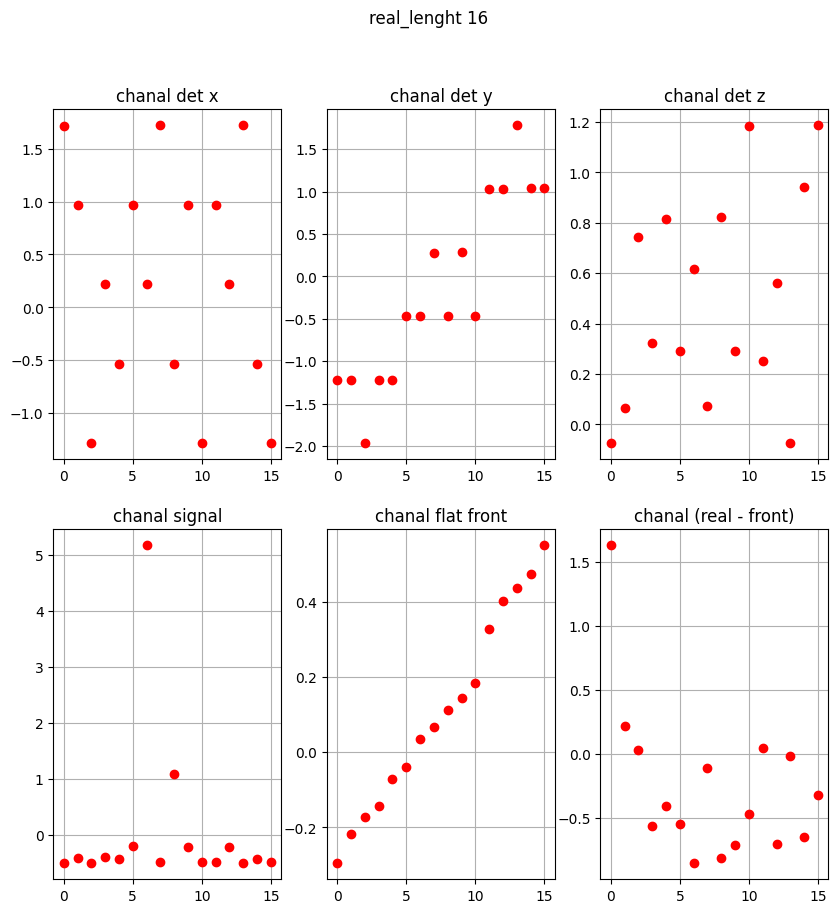

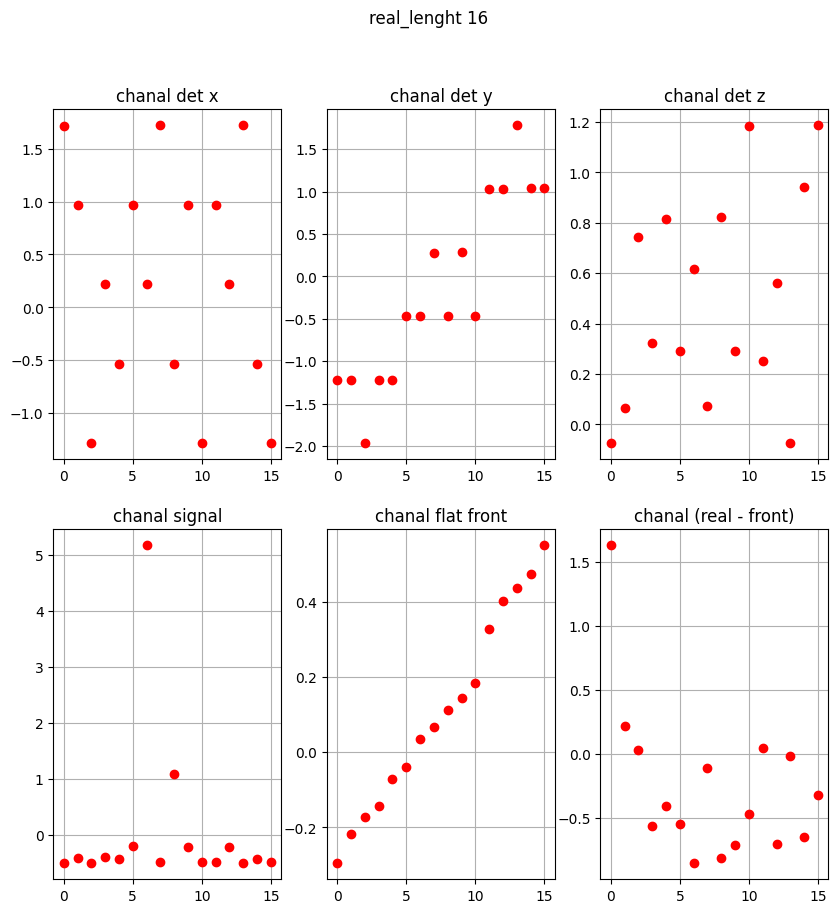

In [8]:
show_data(data[10], tokens = (10, -10, -11))

In [31]:
import os
path_model = '/home/rfit/Telescope_Array/phd_work/Models/AutoEncoder/info_Transfoemr_MMD_0.05_KL_0.01_new_MMD/best'
print(os.path.exists(path_model))
pip.model.load_state_dict(torch.load(path_model))
pip.model.eval()

True


VAE(
  (encoder): Encoder_Transformer(
    (embading): Linear(in_features=6, out_features=64, bias=True)
    (TransformerEncoderLayer): TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (linear1): Linear(in_features=64, out_features=1024, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (linear2): Linear(in_features=1024, out_features=64, bias=True)
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
    (TransformerEncoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
    

In [1]:
fake = pip.model(data.to('cuda:0'))
def show_data_and_fake(data, fake, tokens: Optional[Tuple[int, int, int]]=None,
               lenght_predict: Union[np.ndarray, torch.Tensor] = None) -> plt.figure:
    '''
    data - shape (det, featches)

    fake - shape (det, featches)

    return: fig
    '''

    #TODO переписать нормально
    data, real_lenght = clean_mask(data, tokens = tokens)
    fake = fake[1:real_lenght+1]
    names = ['det x', 'det y', 'det z', 'signal', 'flat front', '(real - front)']
    fig, axs = plt.subplots(2,3, figsize = (10,10))
    for i in range(6):
        row = i//3
        col = i%3
        axs[row][col].plot(data.to('cpu').detach().numpy()[:,i], 'or', label = 'true')
        #axs[row][col].plot(data.to('cpu').detach().numpy()[:,i], '--b')
        axs[row][col].plot(fake.to('cpu').detach().numpy()[:,i], 'og', label = 'fake')
        #axs[row][col].plot(fake.to('cpu').detach().numpy()[:,i], '--k')
        axs[row][col].legend()
        axs[row][col].set_title(f'chanal {names[i]}')
        axs[row][col].grid()
    lenght_info = f'real_lenght {real_lenght}'
    plt.suptitle(lenght_info)
    return fig

NameError: name 'pip' is not defined

In [39]:
fake[0].shape

torch.Size([150, 41, 6])

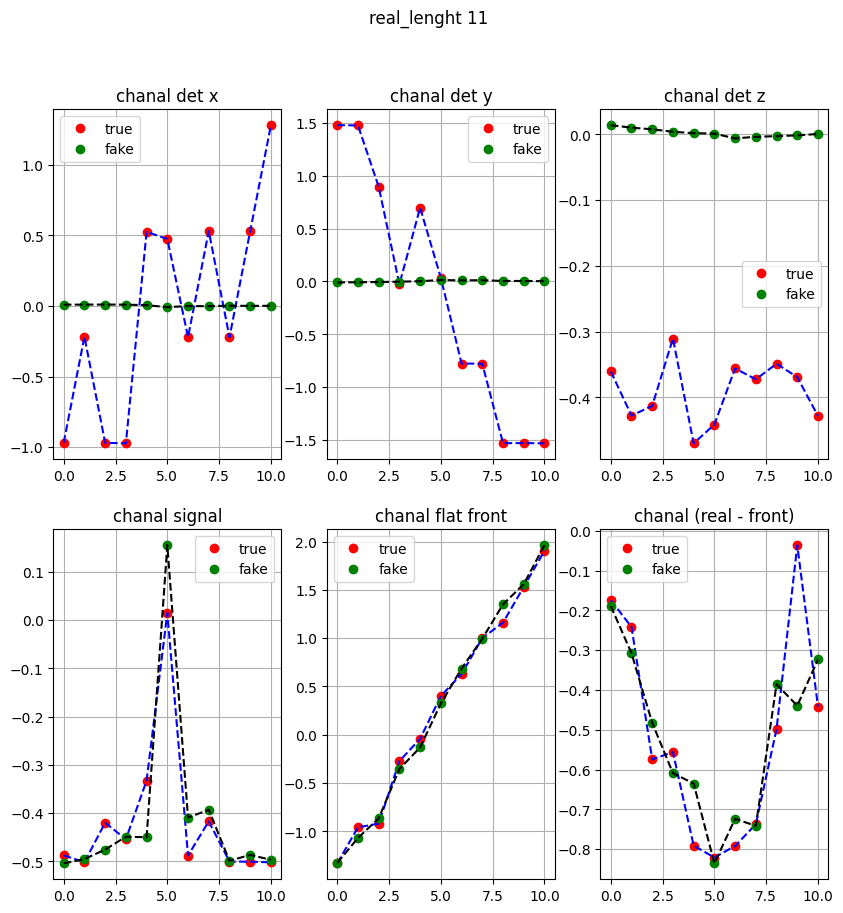

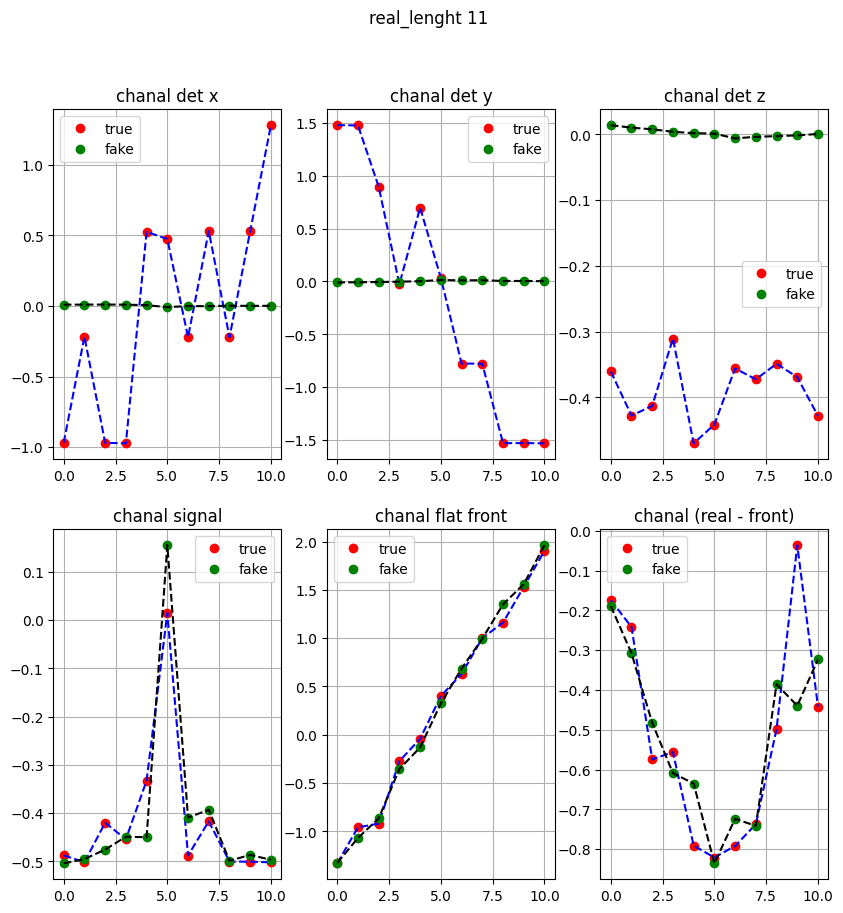

In [41]:
show_data_and_fake(data[11], fake[0][11], tokens = (10, -10, -11))